In [20]:
import jax
import jax.numpy as jnp

# Sanity check: jax.grad of f(x) = x**2 + 3x should give 2x+3
# At x=2.0, expected: 2*2 + 3 = 7
f = lambda x: x**2 + 3*x
df = jax.grad(f)
print(df(2.0))

7.0


In [21]:
# Kill-check 2: single air/glass interface, normal incidence
# R = ((n1-n2)/(n1+n2))**2
n1 = 1.0  # air
n2 = 1.5  # glass

R = ((n1 - n2) / (n1 + n2))**2
T = 1 - R  # no absorption in glass/air
A = 0.0

print(f"R = {R:.4f}")
print(f"T = {T:.4f}")
print(f"A = {A:.4f}")
print(f"R + T + A = {R + T + A:.4f}")

R = 0.0400
T = 0.9600
A = 0.0000
R + T + A = 1.0000


In [22]:
import jax.numpy as jnp

def fresnel_interface(n1, n2):
    """2x2 interface matrix between materials n1 and n2"""
    return jnp.array([[1,    1   ],
                      [n1,  -n2  ]], dtype=complex)

def propagation_matrix(n, d, lam):
    """2x2 propagation matrix through layer of index n, thickness d, wavelength lam"""
    delta = 2 * jnp.pi * n * d / lam
    return jnp.array([[jnp.exp(1j * delta),  0                  ],
                      [0,                     jnp.exp(-1j * delta)]], dtype=complex)

# Test: at d=0, propagation matrix should be identity
P_test = propagation_matrix(1.5, 0.0, 500.0)
print("P at d=0:")
print(P_test)

P at d=0:
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


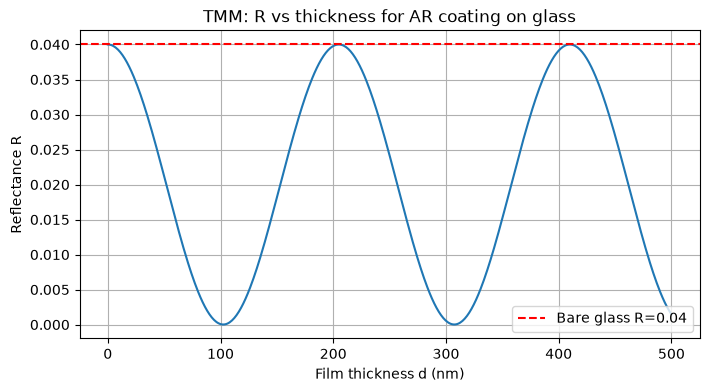

Minimum R: 0.000016 at d=307.6 nm
Maximum R: 0.040000


In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Sweep thickness d from 0 to 500nm
d_values = jnp.linspace(0, 500, 500)
lam = 500.0  # 500nm wavelength (green light)
n0 = 1.0     # air
n1 = 1.22    # ideal AR coating index = sqrt(1.0 * 1.5)
n2 = 1.5     # glass

R_values = [float(tmm_single_layer(n0, n1, n2, d, lam)) for d in d_values]

plt.figure(figsize=(8,4))
plt.plot(d_values, R_values)
plt.axhline(0.04, color='r', linestyle='--', label='Bare glass R=0.04')
plt.xlabel('Film thickness d (nm)')
plt.ylabel('Reflectance R')
plt.title('TMM: R vs thickness for AR coating on glass')
plt.legend()
plt.grid(True)
plt.show()

print(f"Minimum R: {min(R_values):.6f} at d={d_values[jnp.argmin(jnp.array(R_values))]:.1f} nm")
print(f"Maximum R: {max(R_values):.6f}")

In [24]:
import inspect
print(inspect.getsource(tmm_single_layer))

def tmm_single_layer(n0, n1, n2, d, lam):
    """
    TMM for a single layer stack: n0 / layer(n1, d) / n2
    n0: incident medium (air = 1.0)
    n1: layer refractive index  
    n2: substrate (glass = 1.5)
    d: layer thickness in nm
    lam: wavelength in nm
    Returns R
    """
    # Phase thickness of layer
    delta = 2 * jnp.pi * n1 * d / lam

    # Fresnel coefficients at each interface
    r01 = (n0 - n1) / (n0 + n1)  # air -> layer
    r12 = (n1 - n2) / (n1 + n2)  # layer -> glass

    # Total reflection coefficient (Fabry-Perot formula)
    r = (r01 + r12 * jnp.exp(2j * delta)) / (1 + r01 * r12 * jnp.exp(2j * delta))

    R = jnp.abs(r)**2
    return R



In [25]:
def tmm_single_layer(n0, n1, n2, d, lam):
    """
    TMM for a single layer stack: n0 / layer(n1, d) / n2
    n0: incident medium (air = 1.0)
    n1: layer refractive index  
    n2: substrate (glass = 1.5)
    d: layer thickness in nm
    lam: wavelength in nm
    Returns R
    """
    # Phase thickness of layer
    delta = 2 * jnp.pi * n1 * d / lam
    
    # Fresnel coefficients at each interface
    r01 = (n0 - n1) / (n0 + n1)  # air -> layer
    r12 = (n1 - n2) / (n1 + n2)  # layer -> glass
    
    # Total reflection coefficient (Fabry-Perot formula)
    r = (r01 + r12 * jnp.exp(2j * delta)) / (1 + r01 * r12 * jnp.exp(2j * delta))
    
    R = jnp.abs(r)**2
    return R

# Kill-check 3: d=0 should give same R as bare Fresnel (0.04)
R_tmm = tmm_single_layer(1.0, 1.5, 1.5, 0.0, 500.0)
print(f"TMM R at d=0: {R_tmm:.4f}")
print(f"Match with Fresnel: {jnp.abs(R_tmm - 0.04) < 1e-4}")

TMM R at d=0: 0.0400
Match with Fresnel: True
